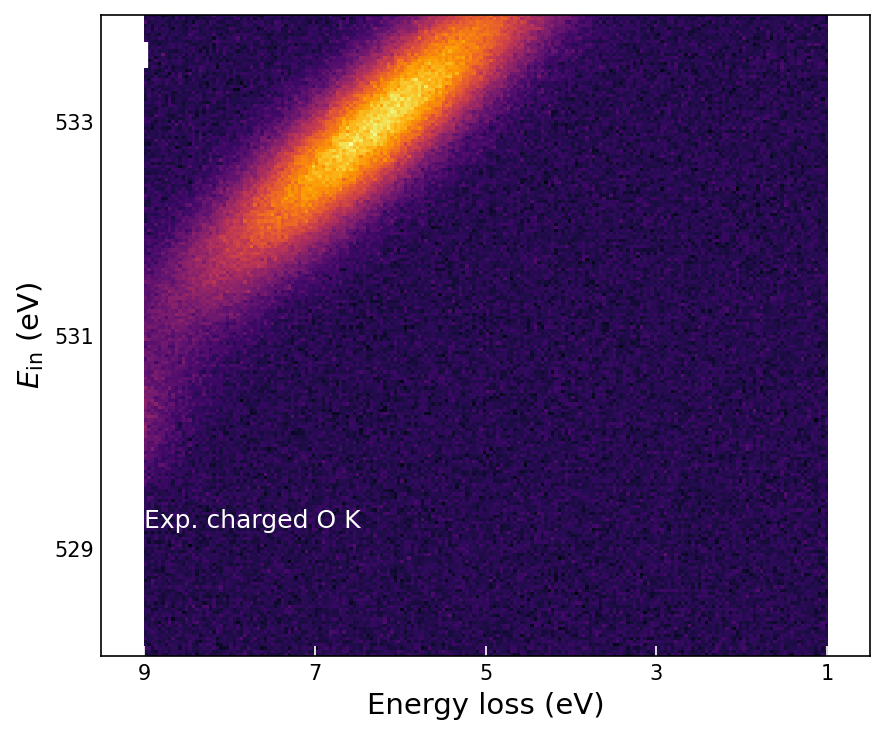

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Axes
energy_loss = np.linspace(9, 1, 200) # Reversed on plot
e_in = np.linspace(528, 534, 200)
EL, EIN = np.meshgrid(energy_loss, e_in)

# Diagonal Features (Raman-like, constant energy loss shift? No, RIXS often has diagonal constant emission or loss features)
# Diagonal streak: Slope -1?
# Let's simulate a streak where E_loss roughly proportional to E_in - offset
# Visual: Top left (534, 7) to Bottom right (528, 2)
# Center line: E_in = -1.2 * E_loss + C
# 534 = -1.2 * 7 + C -> C = 542.4
# 528 = -1.2 * 2 + C -> C = 530.4 (Slope varies or broad)

# Gaussian along a line
def diagonal_gaussian(el, ein, slope, intercept, width):
    dist = (ein - (slope * el + intercept))
    return np.exp(-(dist**2) / (2 * width**2))

# Main Streak (Orange/Yellow)
Z = np.zeros_like(EL)
Z += 1.0 * diagonal_gaussian(EL, EIN, -0.8, 538, 0.5)
# Modulate intensity along the streak (Resonance)
# Intense at E_in ~ 529 and 533
resonance = np.exp(-((EIN - 529)/1)**2) + 0.5 * np.exp(-((EIN - 533)/1.5)**2)
Z *= resonance

# Add noise/background
Z += np.random.normal(0, 0.02, Z.shape)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Heatmap
# 'inferno' or 'magma' matches the black-purple-orange-yellow
cmap = plt.cm.inferno
im = ax.imshow(Z, extent=[9, 1, 528, 534], aspect='auto', cmap=cmap, origin='lower')

# Styling
ax.set_xlabel('Energy loss (eV)', fontsize=14)
ax.set_ylabel(r'$E_{\mathrm{in}}$ (eV)', fontsize=14)
ax.set_xlim(9.5, 0.5) # Reversed axis limits
ax.set_ylim(528, 534)

# Ticks
ax.set_xticks([9, 7, 5, 3, 1])
ax.set_yticks([529, 531, 533])
ax.tick_params(direction='in', color='white', size=5)

# Label
ax.text(9, 529.2, 'Exp. charged O K', color='white', fontsize=12)
ax.text(9.2, 533.5, 'd', color='white', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()
